# Bank Customer Churn Prediction System

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import xgboost as xgb


## Data Loading

In [32]:
df = pd.read_csv('/content/Churn_Modelling.csv')


In [33]:
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Data Overview

In [34]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [35]:
print("\nDescriptive Statistics:")
display(df.describe())


Descriptive Statistics:


,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## Data Cleaning and Preprocessing

In [36]:
# Dropping irrelevant columns
df = df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

print("Dataset after dropping irrelevant columns:")
display(df.head())

Dataset after dropping irrelevant columns:


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


## Exploratory Data Analysis (EDA)

### Target Variable Distribution

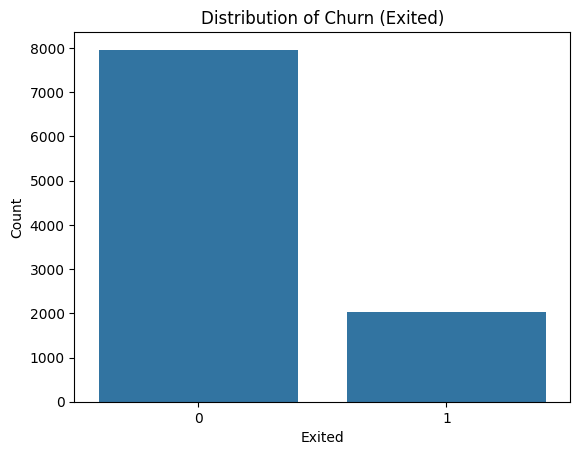

In [37]:
sns.countplot(x='Exited', data=df)
plt.title('Distribution of Churn (Exited)')
plt.xlabel('Exited')
plt.ylabel('Count')
plt.show()

### Categorical Feature Distributions

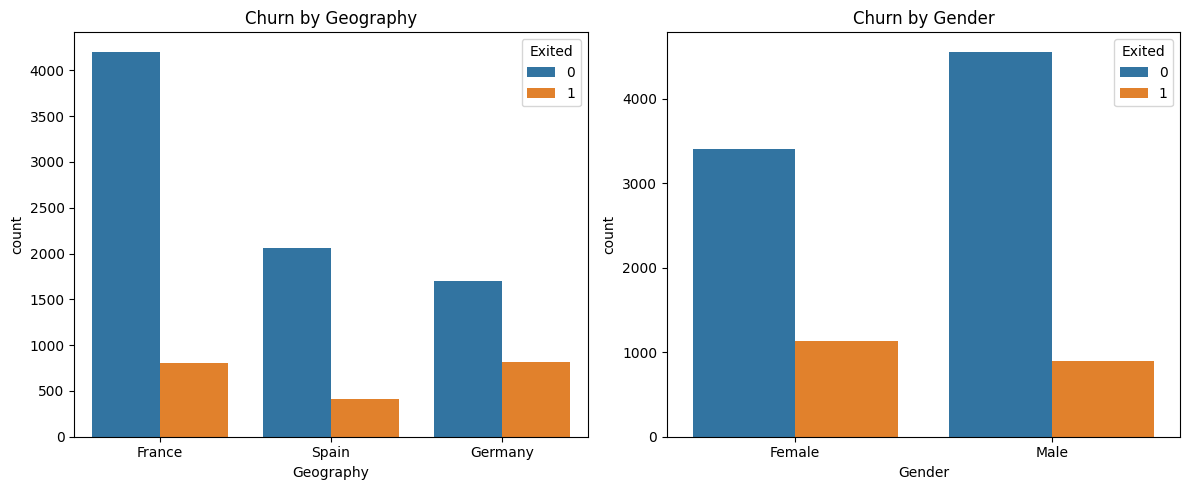

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x='Geography', hue='Exited', data=df, ax=axes[0])
axes[0].set_title('Churn by Geography')
sns.countplot(x='Gender', hue='Exited', data=df, ax=axes[1])
axes[1].set_title('Churn by Gender')
plt.tight_layout()
plt.show()

### Numerical Feature Distributions

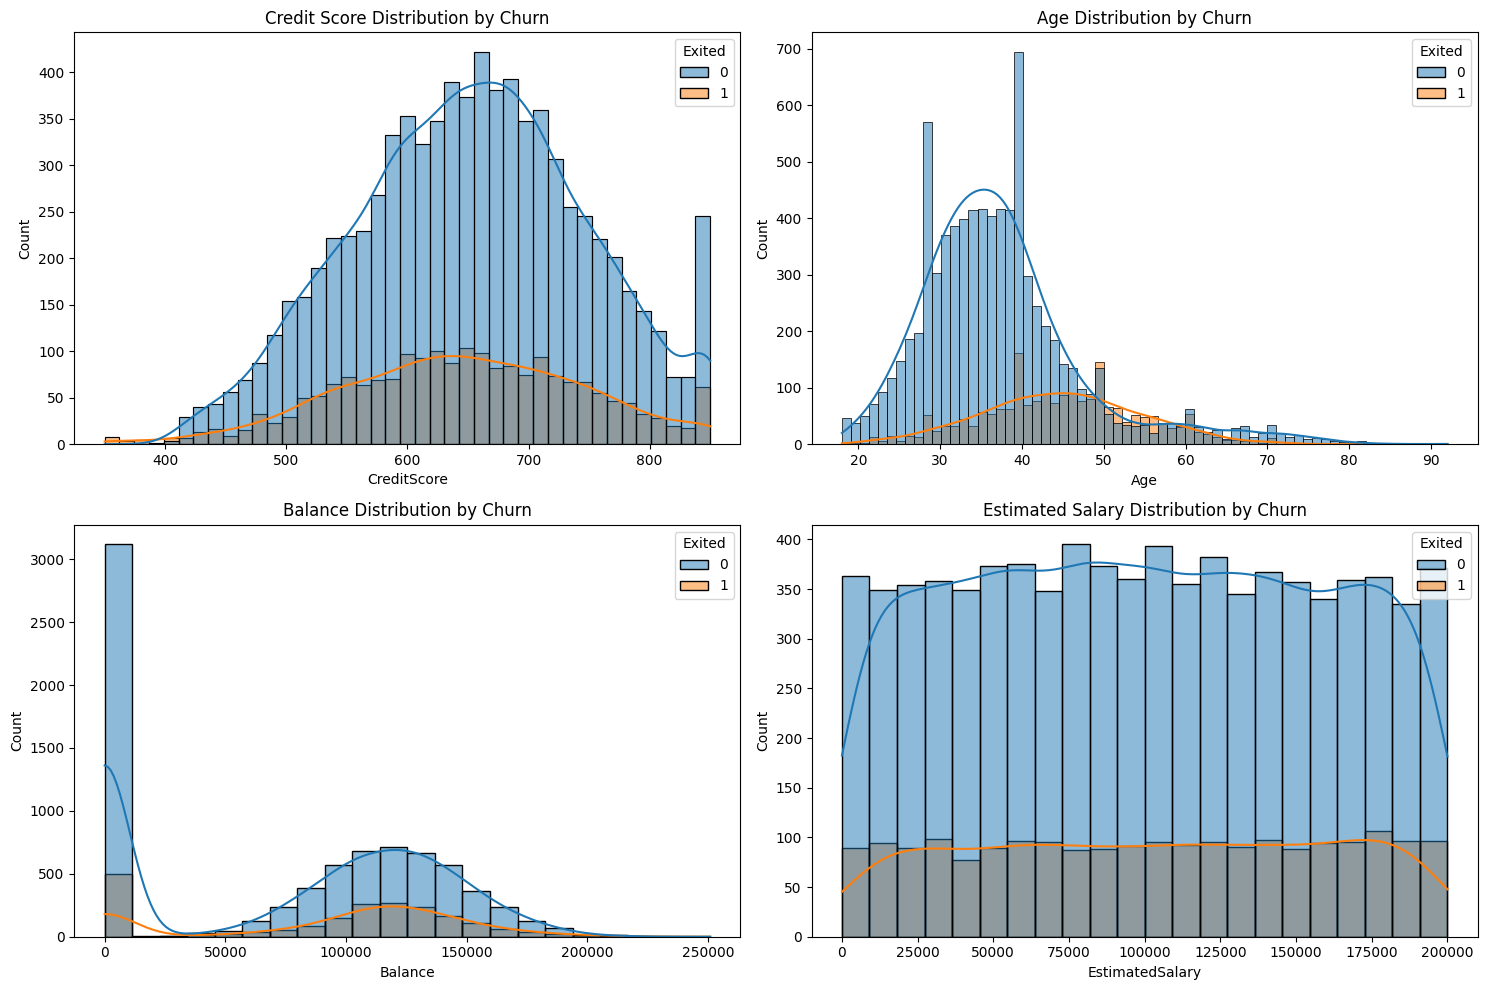

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
sns.histplot(x='CreditScore', hue='Exited', data=df, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Credit Score Distribution by Churn')
sns.histplot(x='Age', hue='Exited', data=df, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Age Distribution by Churn')
sns.histplot(x='Balance', hue='Exited', data=df, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Balance Distribution by Churn')
sns.histplot(x='EstimatedSalary', hue='Exited', data=df, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Estimated Salary Distribution by Churn')
plt.tight_layout()
plt.show()

## Feature Engineering and Encoding

### One-Hot Encoding for Categorical Features

In [40]:
# Apply one-hot encoding to 'Geography' and 'Gender' columns
df = pd.get_dummies(df, columns=['Geography', 'Gender'], drop_first=True)

print("Dataset after One-Hot Encoding:")
display(df.head())

Dataset after One-Hot Encoding:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain,Gender_Male
0,619,42,2,0.00,1,1,1,101348.88,1,False,False,False
1,608,41,1,83807.86,1,0,1,112542.58,0,False,True,False
2,502,42,8,159660.80,3,1,0,113931.57,1,False,False,False
3,699,39,1,0.00,2,0,0,93826.63,0,False,False,False
4,850,43,2,125510.82,1,1,1,79084.10,0,False,True,False


### Feature Scaling

In [41]:
# Separate features (X) and target (y)
X = df.drop('Exited', axis=1)
y = df['Exited']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Identify numerical features for scaling
# Exclude one-hot encoded columns (Geography_Germany, Geography_Spain, Gender_Male) and binary features
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Initialize StandardScaler
scaler = StandardScaler()

# Apply scaling to numerical features in both training and testing sets
X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

print("First 5 rows of scaled training features:")
display(X_train.head())
print("\nFirst 5 rows of scaled testing features:")
display(X_test.head())

First 5 rows of scaled training features:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
2151,1.058568,1.715086,0.684723,-1.226059,-0.910256,0.641042,-1.030206,1.042084,False,False,True
8392,0.913626,-0.659935,-0.696202,0.413288,-0.910256,0.641042,-1.030206,-0.623556,True,False,True
5006,1.079274,-0.184931,-1.731895,0.601687,0.808830,0.641042,0.970680,0.308128,True,False,False
4117,-0.929207,-0.184931,-0.005739,-1.226059,0.808830,0.641042,-1.030206,-0.290199,False,False,True
7182,0.427035,0.955079,0.339492,0.548318,0.808830,-1.559960,0.970680,0.135042,True,False,True



First 5 rows of scaled testing features:


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_Germany,Geography_Spain,Gender_Male
5702,-0.680735,-0.279932,0.684723,-1.226059,0.808830,0.641042,-1.030206,-0.095021,False,False,True
3667,-1.301915,-0.564935,-0.350971,0.877113,0.808830,-1.559960,-1.030206,-0.778941,True,False,True
1617,-0.970619,0.100072,-0.350971,-1.226059,0.808830,-1.559960,0.970680,0.099469,False,True,False
5673,-0.121674,-0.469934,-0.005739,1.011458,0.808830,-1.559960,-1.030206,-1.147374,False,True,True
4272,-0.111321,-0.469934,-0.696202,0.023204,-0.910256,0.641042,0.970680,1.200283,False,True,False


## Model Training and Comparison

### Training Logistic Regression Model

In [42]:
#Initialize and train Logistic Regression model
log_reg_model = LogisticRegression(random_state=42, solver='liblinear')
log_reg_model.fit(X_train, y_train)

# Make predictions
y_pred_log_reg = log_reg_model.predict(X_test)
y_proba_log_reg = log_reg_model.predict_proba(X_test)[:, 1]

# Evaluate Logistic Regression model
print("Logistic Regression Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log_reg):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_log_reg):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_log_reg):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_log_reg):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_log_reg):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_log_reg))

Logistic Regression Model Evaluation:
Accuracy: 0.8085
Precision: 0.5938
Recall: 0.1867
F1-Score: 0.2841
ROC-AUC: 0.7749
Confusion Matrix:
 [[1541   52]
 [ 331   76]]


### Training Random Forest Model

In [43]:
# Initialize and train Random Forest model
# Using class_weight='balanced' to handle potential class imbalance
rf_model = RandomForestClassifier(random_state=42, class_weight='balanced')
rf_model.fit(X_train, y_train)

# Make predictions
y_pred_rf = rf_model.predict(X_test)
y_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate Random Forest model
print("Random Forest Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_rf):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

Random Forest Model Evaluation:
Accuracy: 0.8600
Precision: 0.7773
Recall: 0.4373
F1-Score: 0.5597
ROC-AUC: 0.8508
Confusion Matrix:
 [[1542   51]
 [ 229  178]]


### Training XGBoost Model

In [44]:
# Initialize and train XGBoost model
scale_pos_weight_value = sum(y_train == 0) / sum(y_train == 1)

xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight_value)
xgb_model.fit(X_train, y_train)

# Make predictions
y_pred_xgb = xgb_model.predict(X_test)
y_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate XGBoost model
print("XGBoost Model Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_xgb):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_xgb):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred_xgb):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_xgb):.4f}")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_xgb))

XGBoost Model Evaluation:
Accuracy: 0.8225
Precision: 0.5575
Recall: 0.6192
F1-Score: 0.5867
ROC-AUC: 0.8358
Confusion Matrix:
 [[1393  200]
 [ 155  252]]


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [00:32:13] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Feature Importance Analysis (XGBoost)

Feature Importance (XGBoost):


,Feature,Importance
4,NumOfProducts,0.306822
6,IsActiveMember,0.148712
1,Age,0.126787
8,Geography_Germany,0.095720
3,Balance,0.065953
10,Gender_Male,0.060136
9,Geography_Spain,0.047285
0,CreditScore,0.041731
7,EstimatedSalary,0.041161
2,Tenure,0.037003


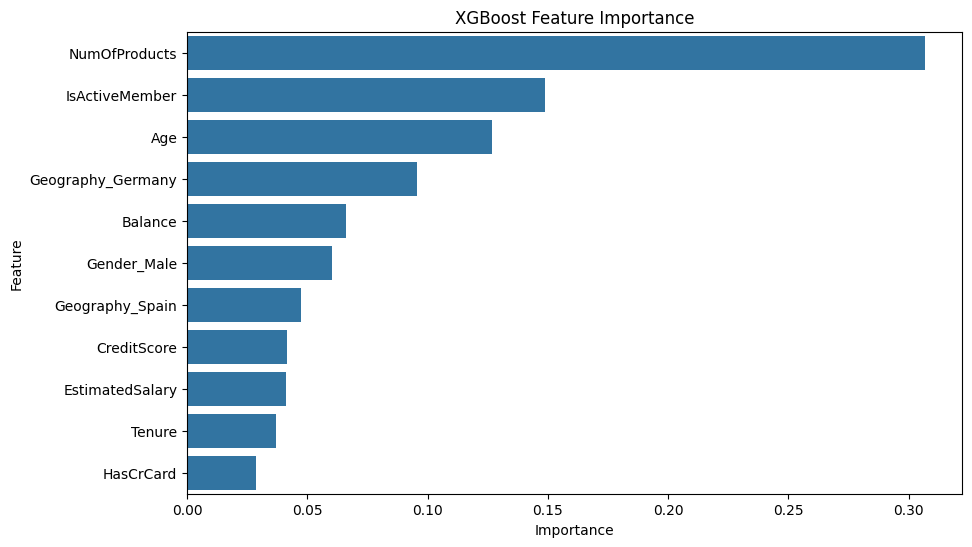

In [45]:
# Get feature importances from the XGBoost model
importance = xgb_model.feature_importances_

# Create a DataFrame for better visualization
feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importance
})

# Sort by importance in descending order
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("Feature Importance (XGBoost):")
display(feature_importance_df)

# Plotting feature importance
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('XGBoost Feature Importance')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

## Churn Probability Scoring System

Top 10 customers by Churn Probability:


,Original_Index,Churn_Probability,Actual_Exited,Churn_Risk_Category
248,6831,0.999937,1,High Risk
860,9540,0.999906,1,High Risk
586,6255,0.999828,1,High Risk
338,5950,0.999816,1,High Risk
1521,1955,0.999760,1,High Risk
1122,4349,0.999708,1,High Risk
1275,3251,0.999645,1,High Risk
1788,2541,0.999640,1,High Risk
1208,1701,0.999549,1,High Risk
94,5922,0.999543,1,High Risk



Churn Risk Category Distribution:


,count
Churn_Risk_Category,
Low Risk,1328
Medium Risk,368
High Risk,304


/tmp/ipykernel_403/773927173.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn_Risk_Category', data=churn_scoring_df, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')


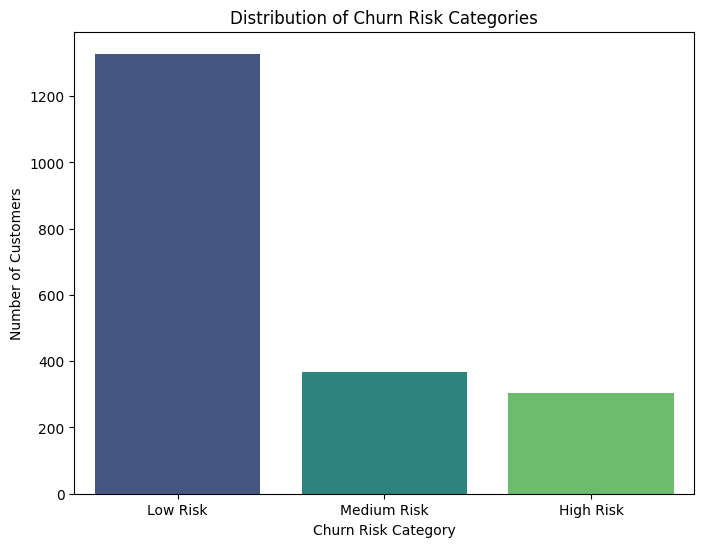

In [46]:
# Get churn probabilities for the test set using the best model (XGBoost)
churn_probabilities = xgb_model.predict_proba(X_test)[:, 1]

# Create a DataFrame to hold customer IDs (if available, otherwise use index) and their churn probabilities
churn_scoring_df = pd.DataFrame({
    'Original_Index': X_test.index,
    'Churn_Probability': churn_probabilities,
    'Actual_Exited': y_test.values
})

# Define churn risk categories
def categorize_churn_risk(probability):
    if probability >= 0.7:
        return 'High Risk'
    elif probability >= 0.3:
        return 'Medium Risk'
    else:
        return 'Low Risk'

churn_scoring_df['Churn_Risk_Category'] = churn_scoring_df['Churn_Probability'].apply(categorize_churn_risk)

print("Top 10 customers by Churn Probability:")
display(churn_scoring_df.sort_values(by='Churn_Probability', ascending=False).head(10))

print("\nChurn Risk Category Distribution:")
display(churn_scoring_df['Churn_Risk_Category'].value_counts())

plt.figure(figsize=(8, 6))
sns.countplot(x='Churn_Risk_Category', data=churn_scoring_df, order=['Low Risk', 'Medium Risk', 'High Risk'], palette='viridis')
plt.title('Distribution of Churn Risk Categories')
plt.xlabel('Churn Risk Category')
plt.ylabel('Number of Customers')
plt.show()

## Business Recommendations

### 1. Targeted Retention Campaigns

*   **High-Risk Customers:** Immediately engage customers identified as 'High Risk' with personalized retention offers. This could include waiving certain fees, offering premium services, or providing dedicated customer support.
*   **Medium-Risk Customers:** Implement proactive outreach. This could involve loyalty programs, financial health check-ups, or surveys to understand their satisfaction levels and address potential pain points before they escalate.
*   **Low-Risk Customers:** Maintain regular, but less intensive, engagement to build long-term relationships, such as newsletters, special offers, and new product announcements.

### 2. Product Offering and Engagement Strategies

*   **Address 'NumOfProducts' Impact:** Since 'NumOfProducts' was the most significant predictor, analyze why customers with fewer products are more likely to churn. It could indicate they are not fully utilizing the bank's ecosystem. Offer incentives to cross-sell additional relevant products (e.g., investment accounts, loans, insurance) to increase their engagement and switching costs. Conversely, for customers with high `NumOfProducts` (e.g. 3 or 4) who are churning, investigate whether these customers are being 'offloaded' or facing issues with complex product portfolios.
*   **Active Membership:** Encourage active participation through various channels. Gamification, rewards for using digital services, or personalized tips for financial management can increase `IsActiveMember` status.

### 3. Demographic and Behavioral Segment-Specific Actions

*   **Age-Specific Interventions:** Tailor offers and communication to different age groups. For instance, older customers (identified as higher churn risk in EDA) might prefer traditional banking services or specific retirement planning advice.
*   **Geographical Focus:** Investigate specific issues in regions like Germany, where churn rates appear higher. This could involve localized marketing, special branch offers, or addressing regional competitor activities.
*   **Balance Management:** Target customers with zero or very low balances. Offer financial planning tools, savings incentives, or credit-building programs to increase their engagement and reliance on the bank.

### 4. Continuous Monitoring and Feedback Loop

*   **Regular Model Updates:** Continuously monitor the model's performance and retrain it with new data periodically to ensure its accuracy and relevance.
*   **Customer Feedback:** Implement channels for customers to provide feedback, especially those identified as medium or high risk, to understand their evolving needs and concerns.